<a href="https://colab.research.google.com/github/chinmayhandi/chinmay/blob/chinmay/AIMI1_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Week-05

1.Detecting outliers

Old Shape: (150, 6)
New Shape: (146, 6)


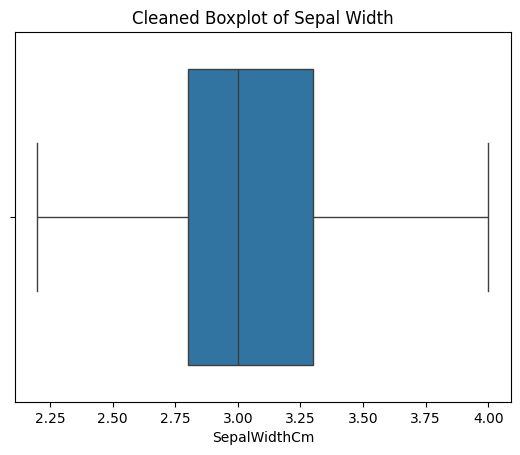

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('/content/iris.csv')

Q1 = np.percentile(df['SepalWidthCm'], 25)
Q3 = np.percentile(df['SepalWidthCm'], 75)
IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR
lower_limit = Q1 - 1.5 * IQR

print("Old Shape:", df.shape)

df = df[(df['SepalWidthCm'] >= lower_limit) & (df['SepalWidthCm'] <= upper_limit)]

print("New Shape:", df.shape)

sns.boxplot(x=df['SepalWidthCm'])
plt.title("Cleaned Boxplot of Sepal Width")
plt.show()

2.Bivariate Outliers Detection:

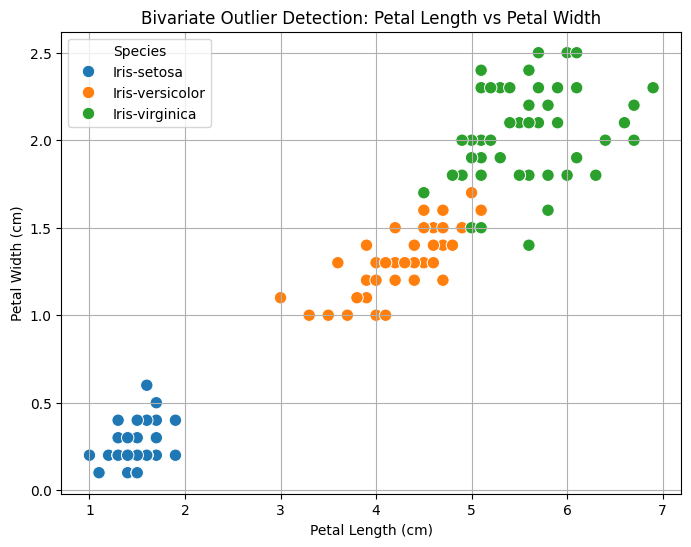

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/iris.csv')

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='PetalLengthCm',
    y='PetalWidthCm',
    hue='Species',
    data=df,
    s=80
)

plt.title('Bivariate Outlier Detection: Petal Length vs Petal Width')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.grid(True)
plt.show()

Week-06

Linear Regression

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df=pd.read_csv('/content/mtcars.csv')
df.head()
df.isnull().sum()

x=df[['wt']]
y=df[['mpg']]

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train, y_train)
y_pred = lr.predict(x_test)
print(y_pred)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
mse=mean_squared_error(y_test, y_pred)
mae=mean_absolute_error(y_test, y_pred)
r2=r2_score(y_test, y_pred)
rmse=np.sqrt(mse)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R-squared:", r2)
print("Root Mean Squared Error:", rmse)

[[22.15398263]
 [ 7.98974016]
 [16.41677063]
 [25.19603923]
 [20.1259449 ]
 [18.5782319 ]
 [17.88442951]]
Mean Squared Error: 12.475985659918818
Mean Absolute Error: 3.004526476081885
R-squared: 0.6879761857596277
Root Mean Squared Error: 3.5321361326991374


Week-07

Random Forest Regressor Model

In [4]:
import pandas as pd
df=pd.read_csv("/content/iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:


from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Species'] = le.fit_transform(df['Species'])

x=df[['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm']]
y=df[['Species']]

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
print(y_pred)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
mse=mean_squared_error(y_test, y_pred)
mae=mean_absolute_error(y_test, y_pred)
r2=r2_score(y_test, y_pred)
rmse=np.sqrt(mse)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R-squared:", r2)
print("Root Mean Squared Error:", rmse)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[1.   0.   2.   1.   1.09 0.   1.   1.99 1.04 1.   2.   0.   0.   0.
 0.   1.04 2.   1.   1.   2.   0.   1.89 0.   2.   2.   2.   2.   2.
 0.   0.  ]
Mean Squared Error: 0.0007833333333333349
Mean Absolute Error: 0.009666666666666676
R-squared: 0.998879173290938
Root Mean Squared Error: 0.02798809270624447


Week-08

Logistic Regression Model

In [6]:
import pandas as pd
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("/content/diabetes.csv")
df.columns = ['pregnant', 'glucose', 'bp', 'skin', 'insulin', 'bmi', 'pedigree', 'age', 'label']
print(df.head())

   pregnant  glucose  bp  skin  insulin   bmi  pedigree  age  label
0         6      148  72    35        0  33.6     0.627   50      1
1         1       85  66    29        0  26.6     0.351   31      0
2         8      183  64     0        0  23.3     0.672   32      1
3         1       89  66    23       94  28.1     0.167   21      0
4         0      137  40    35      168  43.1     2.288   33      1


In [7]:
feature_cols = ['pregnant', 'insulin', 'bmi', 'age','glucose','bp','pedigree']
X = df[feature_cols]
y = df['label']

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.25,random_state=16)
from sklearn.linear_model import LogisticRegression
lg = LogisticRegression(random_state=42, max_iter=1000)
lg.fit(X_train, y_train)
y_pred = lg.predict(X_test)
print(y_pred)

[1 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 1 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 0 1 1 0 1 0 0 0 0 1 0
 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 0 1 1 1 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0 0 1 0
 0 1 1 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1
 0 0 0 1 0 0 1 0 0 0 1 0 0 1 1 0 0 0 0 1 0 0 0 0 0 1 0 0 1 0 1 1 0 0 0 1 0
 1 1 0 0 0 1 1]


Confusion Matrix:
 [[115  10]
 [ 25  42]]


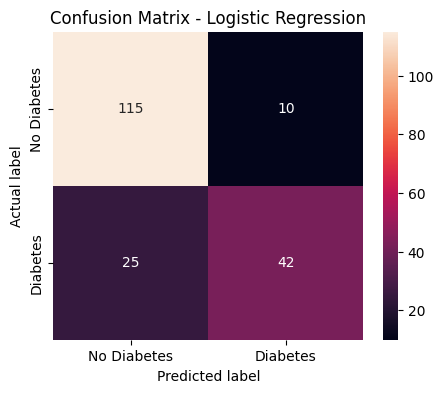

In [9]:
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cnf_matrix)

plt.figure(figsize=(5,4))
sns.heatmap(pd.DataFrame(cnf_matrix),annot=True,fmt='d',
            xticklabels=["No Diabetes", "Diabetes"],
            yticklabels=["No Diabetes", "Diabetes"])

plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

Build a Support Vector Machine (SVM) model using the Breast Cancer Dataset

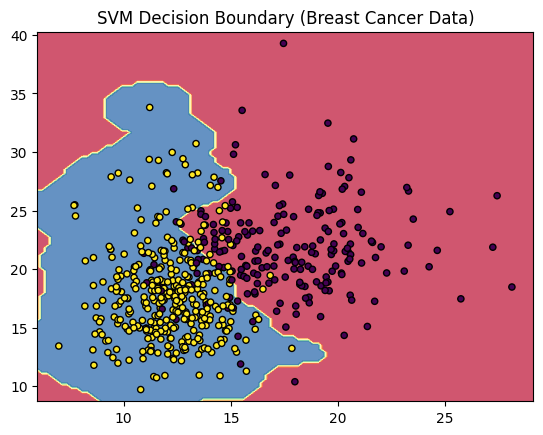

In [10]:
from sklearn.datasets import load_breast_cancer
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.svm import SVC
cancer = load_breast_cancer()
X = cancer.data[:, :2] # Use only first 2 features for visualization
y = cancer.target
svm = SVC(kernel="rbf", gamma=0.5, C=1.0)
svm.fit(X, y)
DecisionBoundaryDisplay.from_estimator(svm,X,
                                       response_method="predict",
                                       cmap=plt.cm.Spectral,
                                       alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y,s=20, edgecolors="k")
plt.title("SVM Decision Boundary (Breast Cancer Data)")
plt.xlabel=cancer.feature_names[0]
plt.ylabel=cancer.feature_names[1]
plt.show()

3. Averaging method:

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.linear_model import LinearRegression

df = pd.read_csv("/content/train_data_combined.csv")

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Weekday'] = le.fit_transform(df['Weekday'])

target = df["target"]
train = df.drop("target", axis=1)

X_train, X_test, y_train, y_test = train_test_split(train, target, test_size=0.20, random_state=42)

model_1 = LinearRegression()
model_2 = xgb.XGBRegressor()
model_3 = RandomForestRegressor()

model_1.fit(X_train, y_train)
model_2.fit(X_train, y_train)
model_3.fit(X_train, y_train)

pred_1 = model_1.predict(X_test)
pred_2 = model_2.predict(X_test)
pred_3 = model_3.predict(X_test)

pred_final = (pred_1 + pred_2 + pred_3) / 3.0

print("Mean Squared Error:", mean_squared_error(y_test, pred_final))

Mean Squared Error: 97.06000438118527


RandomForestClassifier model Model

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
df = pd.read_csv("/content/diabetes.csv")
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [13]:
feature_cols = ['Glucose', 'BMI', 'Age', 'Insulin']
X = df[feature_cols]
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print(y_pred)

[1 0 0 0 1 1 0 1 0 1 1 1 0 0 0 0 0 0 1 1 0 0 0 0 1 1 0 0 0 0 1 1 1 1 1 1 1
 1 0 1 0 0 1 0 0 1 1 0 0 1 0 1 1 0 0 0 1 0 0 1 1 0 0 0 0 1 0 1 0 1 1 0 0 0
 0 1 0 0 0 0 1 0 0 1 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 0 1 0 1 1 1 0 0 1 0 1 0
 1 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 0 1 1 1 0 1 1 0 0 0 0 0 0 0 0 0
 0 1 0 1 0 0 0 1 0 0 1 0 0 1 0 0 0 1 0 1 1 0 1 0 0 1 1 0 1 0 0 1 0 0 1 1 1
 0 0 0 1 0 0 0]


In [14]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["No Diabetes", "Diabetes"]))

Confusion Matrix:
 [[92 31]
 [22 47]]

Classification Report:

              precision    recall  f1-score   support

 No Diabetes       0.81      0.75      0.78       123
    Diabetes       0.60      0.68      0.64        69

    accuracy                           0.72       192
   macro avg       0.70      0.71      0.71       192
weighted avg       0.73      0.72      0.73       192



Week-09

Kmeans

TypeError: 'numpy.str_' object is not callable

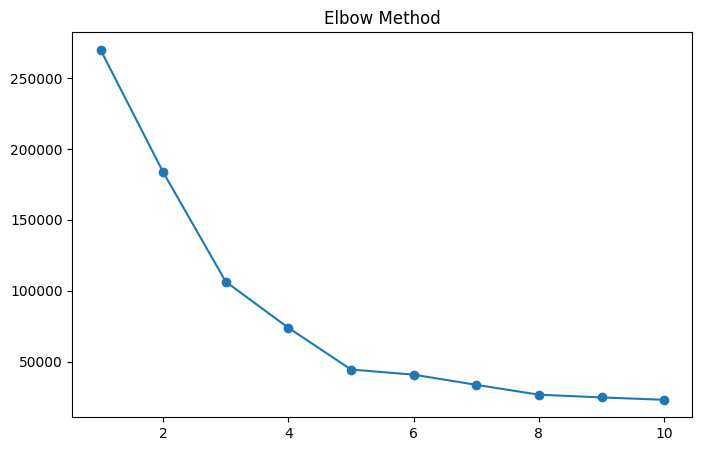

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

data = pd.read_csv("/content/Mall_Customers.csv")
data.head()

X = data.iloc[:, [3, 4]].values

wcss = []
for i in range(1, 11):
  kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
  kmeans.fit(X)
  wcss.append(kmeans.inertia_)
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()



Cluster labels (y): [4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4
 2 4 2 4 2 4 0 4 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 3 1 0 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 0 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]


TypeError: 'numpy.str_' object is not callable

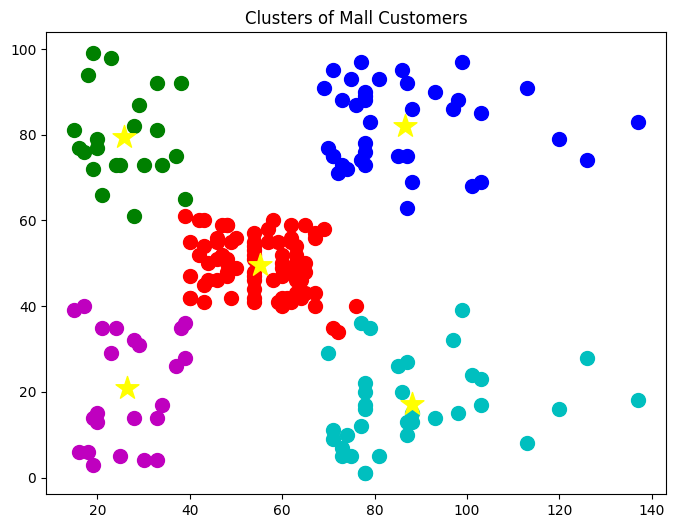

In [16]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_pre = kmeans.fit_predict(X)
print("Cluster labels (y):", y_pre)

plt.figure(figsize=(8,6))
plt.scatter(X[y_pre == 0, 0], X[y_pre == 0, 1], s=100, c='r', label='Cluster 1')
plt.scatter(X[y_pre == 1, 0], X[y_pre == 1, 1], s=100, c='b', label='Cluster 2')
plt.scatter(X[y_pre == 2, 0], X[y_pre == 2, 1], s=100, c='g', label='Cluster 3')
plt.scatter(X[y_pre == 3, 0], X[y_pre == 3, 1], s=100, c='c', label='Cluster 4')
plt.scatter(X[y_pre == 4, 0], X[y_pre == 4, 1], s=100, c='m', label='Cluster 5')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],s=300, c='yellow', marker='*',
label='Centroids')

plt.title("Clusters of Mall Customers")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1–100)")
plt.legend()
plt.show()

Building deep learning model withTensorFlow and Keras for use cases%load_exttensorboard

In [19]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.callbacks import TensorBoard
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
model = Sequential([
Flatten(input_shape=(28, 28)),
Dense(128, activation='relu'),
Dense(10, activation='softmax')
])
model.compile(optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy'])
tensorboard_callback = TensorBoard(log_dir='./logs', histogram_freq=1)
model.fit(x_train, y_train, epochs=5, batch_size=32,
validation_data=(x_test, y_test),
callbacks=[tensorboard_callback])
test_loss, test_acc = model.evaluate(x_test, y_test)
print('Test accuracy:', test_acc)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.8790 - loss: 0.4354 - val_accuracy: 0.9589 - val_loss: 0.1446
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9650 - loss: 0.1213 - val_accuracy: 0.9713 - val_loss: 0.0973
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9753 - loss: 0.0809 - val_accuracy: 0.9737 - val_loss: 0.0840
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9832 - loss: 0.0565 - val_accuracy: 0.9739 - val_loss: 0.0796
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9864 - loss: 0.0431 - val_accuracy: 0.9761 - val_loss: 0.0831
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9728 - loss: 0.0996
Test accuracy: 0.9761000275611877


week-11

Unigram,bigram,trigram

In [20]:
import spacy
from nltk import ngrams
nlp = spacy.load("en_core_web_sm")
doc = nlp("I reside in Bengaluru")
grams = ngrams(doc,1)
print(list(grams))

[(I,), (reside,), (in,), (Bengaluru,)]


In [21]:
import spacy
from nltk import ngrams
nlp = spacy.load("en_core_web_sm")
doc = nlp("I reside in Bengaluru")
bigrams = ngrams(doc,2)
print(list(bigrams))

[(I, reside), (reside, in), (in, Bengaluru)]


In [22]:
import spacy
from nltk import ngrams
nlp = spacy.load("en_core_web_sm")
doc = nlp("I reside in Bengaluru")
trigrams = ngrams(doc,3)
print(list(trigrams))

[(I, reside, in), (reside, in, Bengaluru)]


Bag of words model.

In [23]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

sent1 = "India is a republic country. We are proud Indians."
sent2="The current Prime Minister of India is Shri. Narendra Modi."


cv = CountVectorizer()
dtm = cv.fit_transform([sent1, sent2])

print(pd.DataFrame(dtm.toarray(), columns=cv.get_feature_names_out()))

   are  country  current  india  indians  is  minister  modi  narendra  of  \
0    1        1        0      1        1   1         0     0         0   0   
1    0        0        1      1        0   1         1     1         1   1   

   prime  proud  republic  shri  the  we  
0      0      1         1     0    0   1  
1      1      0         0     1    1   0  
